<a href="https://colab.research.google.com/github/Shas1234-cyber/CODSOFT/blob/main/Copy_of_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

print("✅ Libraries imported successfully!")

try:
    df = pd.read_csv('traffic_dataset_with_trend.csv')
    print("✅ Dataset loaded successfully!")
    print(f"Total records: {len(df)}")
    print("\nFirst 3 rows of data:")
    print(df.head(3))
except FileNotFoundError:
    print("❌ Error: 'Traffic_Time_Series_Dataset.csv' not found. Please upload it to Colab.")

✅ Libraries imported successfully!
✅ Dataset loaded successfully!
Total records: 8736

First 3 rows of data:
             Timestamp Weather  Events  Traffic Volume
0  2023-01-01 00:00:00  Cloudy   False           803.0
1  2023-01-01 01:00:00   Clear   False           861.0
2  2023-01-01 02:00:00   Clear   False           582.0


📊 Generating Visualizations...


/tmp/ipykernel_7862/3915883143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Weather', y='Traffic Volume', palette='viridis')


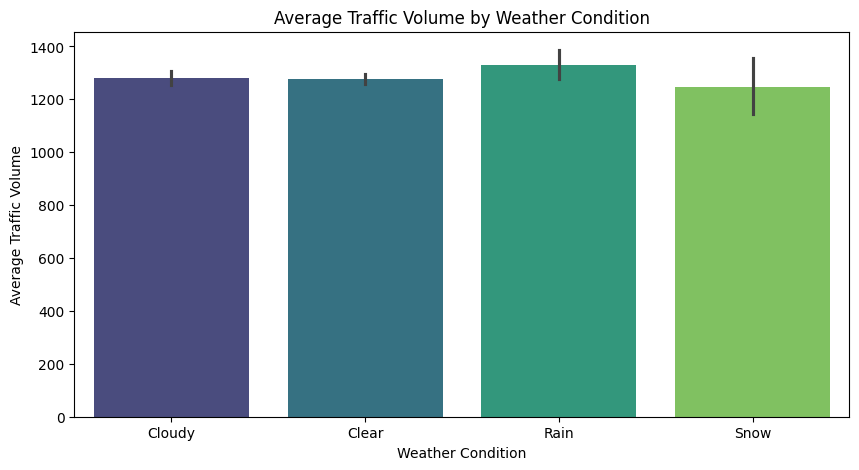

This graph shows which weather conditions cause the most congestion.


In [ ]:
# Part 2: Exploratory Data Analysis (EDA)
print("📊 Generating Visualizations...")

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Weather', y='Traffic Volume', palette='viridis')
plt.title('Average Traffic Volume by Weather Condition')
plt.ylabel('Average Traffic Volume')
plt.xlabel('Weather Condition')
plt.show()

print("This graph shows which weather conditions cause the most congestion.")

In [20]:
# Part 3: Data Preprocessing
print("⚙️ Processing Data for AI...")

# 1. Convert Timestamp to numerical features (Hour and Day)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# 2. Convert Weather Text ('Rain', 'Clear') to Numbers
weather_encoder = LabelEncoder()
df['Weather_Encoded'] = weather_encoder.fit_transform(df['Weather'])
print("Weather encoding mapping:", dict(zip(weather_encoder.classes_, weather_encoder.transform(weather_encoder.classes_))))

# 3. Convert Events (True/False) to Numbers (1/0)
df['Events_Encoded'] = df['Events'].astype(int)

# 4. Define Features (Inputs) and Target (Output)
features = ['Hour', 'DayOfWeek', 'Weather_Encoded', 'Events_Encoded']
X = df[features]
y = df['Traffic Volume']

print("\n✅ Data preprocessing complete! Features ready.")

⚙️ Processing Data for AI...
Weather encoding mapping: {'Clear': np.int64(0), 'Cloudy': np.int64(1), 'Rain': np.int64(2), 'Snow': np.int64(3)}

✅ Data preprocessing complete! Features ready.


In [21]:
# Part 4: Model Training
print("🚀 Splitting Data (80% Training, 20% Testing)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} records...")

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ Model Training Complete!")

🚀 Splitting Data (80% Training, 20% Testing)...
Training on 6988 records...
✅ Model Training Complete!


📈 Evaluating Model Performance...
Model Accuracy (R-squared): 54.20%
Average Error (MAE): 293.52 vehicles


/tmp/ipykernel_7862/2491182048.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette='mako')


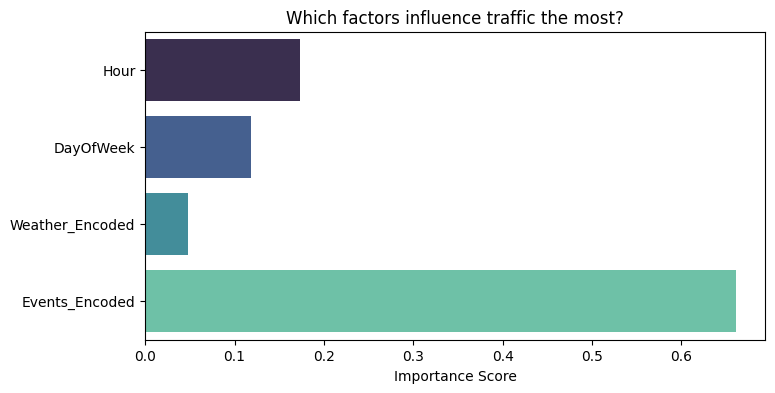

In [24]:
# Part 5: Model Evaluation
print("📈 Evaluating Model Performance...")

y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Accuracy (R-squared): {r2*100:.2f}%")
print(f"Average Error (MAE): {mae:.2f} vehicles")

importance = model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importance, y=features, palette='mako')
plt.title('Which factors influence traffic the most?')
plt.xlabel('Importance Score')
plt.show()

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import gradio as gr

print("1. Loading Data and Training AI... Please wait.")

# --- PART A: DATA PREP & TRAINING ---
df = pd.read_csv('traffic_dataset_with_trend.csv')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

weather_encoder = LabelEncoder()
df['Weather_Encoded'] = weather_encoder.fit_transform(df['Weather'])
df['Events_Encoded'] = df['Events'].astype(int)

X = df[['Hour', 'DayOfWeek', 'Weather_Encoded', 'Events_Encoded']]
y = df['Traffic Volume']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ AI Trained Successfully! Launching Dashboard...")

# --- PART B: GRADIO DASHBOARD ---
def predict_traffic(hour, day_name, weather_name, is_event):
    day_map = {"Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6}
    day_encoded = day_map[day_name]

    try:
        weather_encoded = weather_encoder.transform([weather_name])[0]
    except:
        weather_encoded = 0

    event_encoded = 1 if is_event == "Yes" else 0

    input_data = pd.DataFrame([[hour, day_encoded, weather_encoded, event_encoded]],
                              columns=['Hour', 'DayOfWeek', 'Weather_Encoded', 'Events_Encoded'])

    prediction = model.predict(input_data)[0]

    if prediction > 3000:
        status = "🔴 SEVERE CONGESTION"
        advice = "Avoid route. High probability of traffic jams and delays."
    elif prediction > 1500:
        status = "🟡 MODERATE TRAFFIC"
        advice = "Standard city flow. Minor slowdowns expected."
    else:
        status = "🟢 CLEAR ROADS"
        advice = "Smooth driving conditions. Optimal time to travel."

    return f"{int(prediction)} Vehicles/Hour", status, advice

my_theme = gr.themes.Soft(primary_hue="indigo", secondary_hue="blue")

with gr.Blocks(theme=my_theme) as modern_dashboard:
    gr.Markdown("<h1 style='text-align: center;'>🚦 Smart City Traffic Predictor AI</h1>")
    gr.Markdown("<h3 style='text-align: center; color: gray;'>SDG Goal 11: Sustainable Cities & Communities</h3>")

    with gr.Row():
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### ⚙️ Input Parameters")
            hour_input = gr.Slider(minimum=0, maximum=23, step=1, label="Time of Day (24-Hour Format)", value=17)
            day_input = gr.Dropdown(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], label="Day of the Week", value="Monday")

            weather_classes = list(weather_encoder.classes_)
            weather_input = gr.Dropdown(choices=weather_classes, label="Current Weather", value=weather_classes[0])

            event_input = gr.Radio(["Yes", "No"], label="Is there a special city event today?", value="No")

            predict_btn = gr.Button("🔮 Predict Traffic Flow", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 AI Real-Time Analysis")
            volume_output = gr.Textbox(label="Predicted Volume", placeholder="Waiting for AI...", lines=2)
            status_output = gr.Textbox(label="Road Status Indicator", placeholder="Waiting for AI...", lines=2)
            advice_output = gr.Textbox(label="AI Recommendation", placeholder="Waiting for AI...", lines=2)

    predict_btn.click(
        fn=predict_traffic,
        inputs=[hour_input, day_input, weather_input, event_input],
        outputs=[volume_output, status_output, advice_output]
    )

# Launch normally!
modern_dashboard.launch()

1. Loading Data and Training AI... Please wait.
✅ AI Trained Successfully! Launching Dashboard...


/tmp/ipykernel_7862/3655110739.py:60: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=my_theme) as modern_dashboard:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2355957163a82fcaa4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
import pandas as pd
import requests  # ✅ NEW: For API
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import gradio as gr

print("1. Loading Data and Training AI... Please wait.")

# --- PART A: DATA PREP & TRAINING ---
df = pd.read_csv('traffic_dataset_with_trend.csv')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

weather_encoder = LabelEncoder()
df['Weather_Encoded'] = weather_encoder.fit_transform(df['Weather'])
df['Events_Encoded'] = df['Events'].astype(int)

X = df[['Hour', 'DayOfWeek', 'Weather_Encoded', 'Events_Encoded']]
y = df['Traffic Volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ AI Trained Successfully! Launching Dashboard...")

# --- 🔥 PART B: WEATHER API FUNCTION ---
def get_live_weather(city):
    api_key = "bfda9cfd2e90e13ff663d19e88a6018d"  # 🔴 Replace with your API key

    try:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}"
        response = requests.get(url).json()

        weather = response['weather'][0]['main']

        # Map API weather → dataset categories
        if weather.lower() in ["clear"]:
            return "Clear"
        elif weather.lower() in ["clouds"]:
            return "Cloudy"
        elif weather.lower() in ["rain", "drizzle"]:
            return "Rainy"
        else:
            return "Clear"  # default fallback

    except:
        return "Clear"  # safe fallback if API fails


# --- PART C: GRADIO DASHBOARD ---
def predict_traffic(hour, day_name, city, is_event):
    day_map = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
    }
    day_encoded = day_map[day_name]

    # 🔥 Get LIVE weather instead of manual input
    weather_name = get_live_weather(city)

    try:
        weather_encoded = weather_encoder.transform([weather_name])[0]
    except:
        weather_encoded = 0

    event_encoded = 1 if is_event == "Yes" else 0

    input_data = pd.DataFrame(
        [[hour, day_encoded, weather_encoded, event_encoded]],
        columns=['Hour', 'DayOfWeek', 'Weather_Encoded', 'Events_Encoded']
    )

    prediction = model.predict(input_data)[0]

    if prediction > 3000:
        status = "🔴 SEVERE CONGESTION"
        advice = "Avoid route. High probability of traffic jams and delays."
    elif prediction > 1500:
        status = "🟡 MODERATE TRAFFIC"
        advice = "Standard city flow. Minor slowdowns expected."
    else:
        status = "🟢 CLEAR ROADS"
        advice = "Smooth driving conditions. Optimal time to travel."

    return f"{int(prediction)} Vehicles/Hour", status, advice, weather_name


# --- UI ---
my_theme = gr.themes.Soft(primary_hue="indigo", secondary_hue="blue")

with gr.Blocks(theme=my_theme) as modern_dashboard:
    gr.Markdown("<h1 style='text-align: center;'>🚦 Smart City Traffic Predictor AI</h1>")
    gr.Markdown("<h3 style='text-align: center; color: gray;'>SDG Goal 11: Sustainable Cities & Communities</h3>")

    with gr.Row():
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### ⚙️ Input Parameters")

            hour_input = gr.Slider(0, 23, step=1, label="Time of Day", value=17)

            day_input = gr.Dropdown(
                ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
                label="Day of the Week",
                value="Monday"
            )

            # 🔥 NEW: City input instead of weather dropdown
            city_input = gr.Textbox(label="Enter City (e.g., Delhi)", value="Delhi")

            event_input = gr.Radio(["Yes", "No"], label="Is there a special city event today?", value="No")

            predict_btn = gr.Button("🔮 Predict Traffic Flow", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 AI Real-Time Analysis")

            volume_output = gr.Textbox(label="Predicted Volume", lines=2)
            status_output = gr.Textbox(label="Road Status Indicator", lines=2)
            advice_output = gr.Textbox(label="AI Recommendation", lines=2)

            # 🔥 NEW: Show live weather used
            weather_output = gr.Textbox(label="Live Weather (API)", lines=1)

    predict_btn.click(
        fn=predict_traffic,
        inputs=[hour_input, day_input, city_input, event_input],
        outputs=[volume_output, status_output, advice_output, weather_output]
    )

modern_dashboard.launch()

1. Loading Data and Training AI... Please wait.
✅ AI Trained Successfully! Launching Dashboard...


/tmp/ipykernel_7862/4019146980.py:96: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=my_theme) as modern_dashboard:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1b6c9bb6a5364f64ff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
